In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [4]:
# Load the dataset
df = pd.read_csv("../Dataset/USA_Housing.csv")

# Display first 5 rows
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [5]:
# Check number of rows and columns
df.shape

(5000, 7)

In [6]:
# Display column names
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

In [7]:
# Check data types
df.dtypes

Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                             str
dtype: object

In [9]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 499.6 KB


In [8]:
# Check missing values
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [10]:
"../Dataset/USA_Housing.csv"

'../Dataset/USA_Housing.csv'

In [11]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [12]:
# Remove Address column
df = df.drop(columns=["Address"])

# Check the updated columns
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='str')

In [13]:
# Check minimum values of numeric columns
df.min()

Avg. Area Income                17796.631190
Avg. Area House Age                 2.644304
Avg. Area Number of Rooms           3.236194
Avg. Area Number of Bedrooms        2.000000
Area Population                   172.610686
Price                           15938.657923
dtype: float64

In [14]:
# Check for negative values
(df < 0).sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
dtype: int64

In [15]:
# Rename columns for easier coding
df = df.rename(columns={
    "Avg. Area Income": "avg_area_income",
    "Avg. Area House Age": "avg_area_house_age",
    "Avg. Area Number of Rooms": "avg_area_number_of_rooms",
    "Avg. Area Number of Bedrooms": "avg_area_number_of_bedrooms",
    "Area Population": "area_population",
    "Price": "price"
})

# Display column names
df.columns

Index(['avg_area_income', 'avg_area_house_age', 'avg_area_number_of_rooms',
       'avg_area_number_of_bedrooms', 'area_population', 'price'],
      dtype='str')

In [16]:
# Display cleaned dataset
df.head()

,avg_area_income,avg_area_house_age,avg_area_number_of_rooms,avg_area_number_of_bedrooms,area_population,price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [17]:
# Check dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   avg_area_income              5000 non-null   float64
 1   avg_area_house_age           5000 non-null   float64
 2   avg_area_number_of_rooms     5000 non-null   float64
 3   avg_area_number_of_bedrooms  5000 non-null   float64
 4   area_population              5000 non-null   float64
 5   price                        5000 non-null   float64
dtypes: float64(6)
memory usage: 234.5 KB


In [18]:
# Display statistical summary
df.describe()

,avg_area_income,avg_area_house_age,avg_area_number_of_rooms,avg_area_number_of_bedrooms,area_population,price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


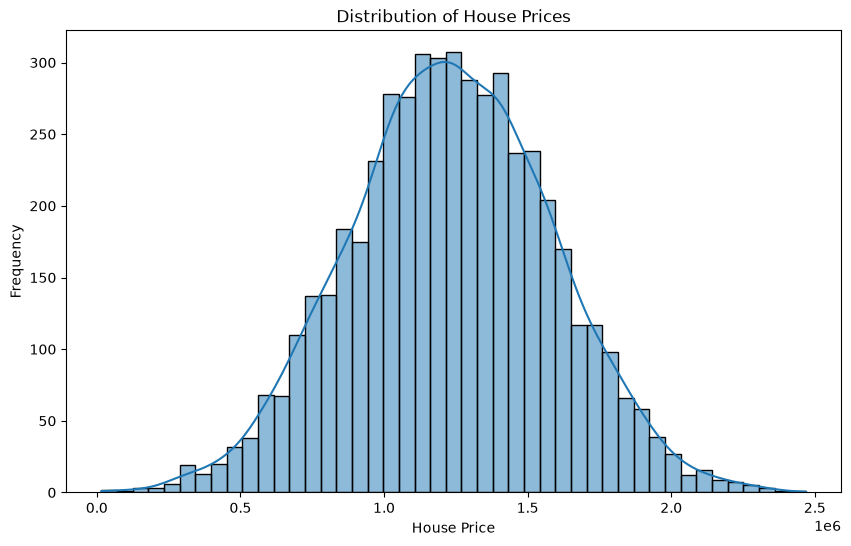

In [19]:
# Price distribution
plt.figure(figsize=(10, 6))

sns.histplot(df["price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

In [20]:
plt.savefig("../Images/price_distribution.png")

<Figure size 640x480 with 0 Axes>

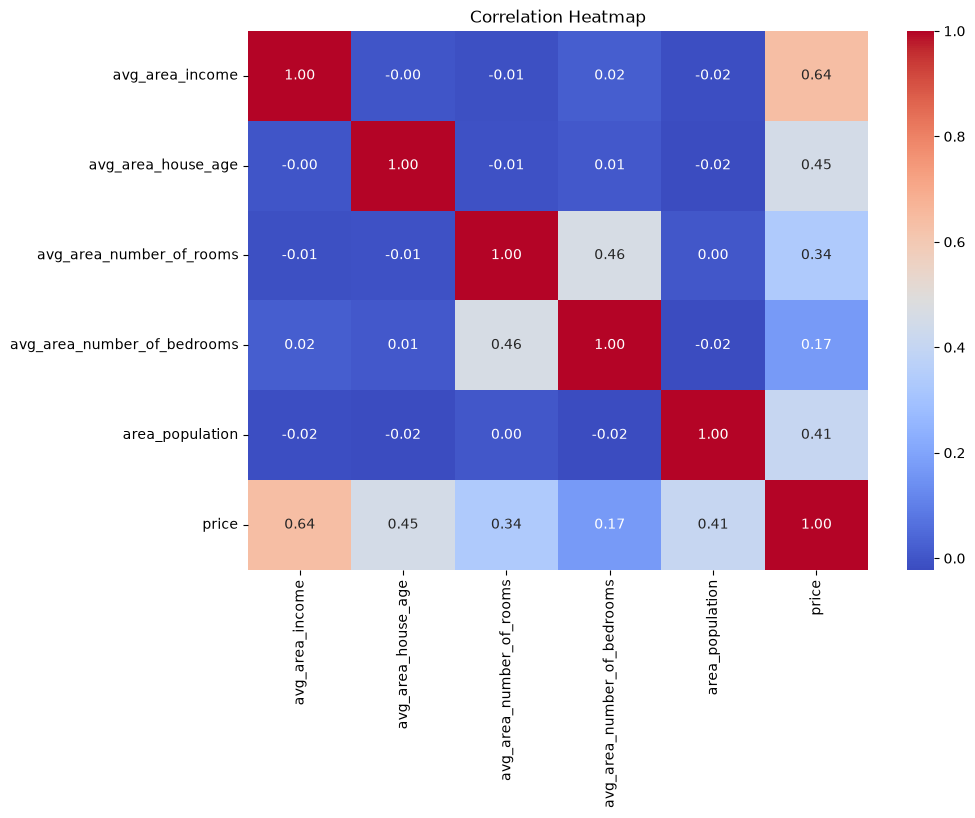

In [21]:
# Correlation heatmap
plt.figure(figsize=(10, 7))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

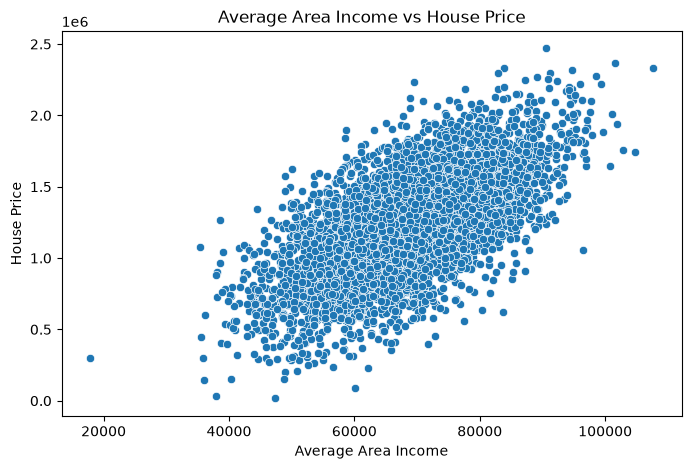

In [22]:
# Average Area Income vs Price
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="avg_area_income",
    y="price"
)

plt.title("Average Area Income vs House Price")
plt.xlabel("Average Area Income")
plt.ylabel("House Price")

plt.show()

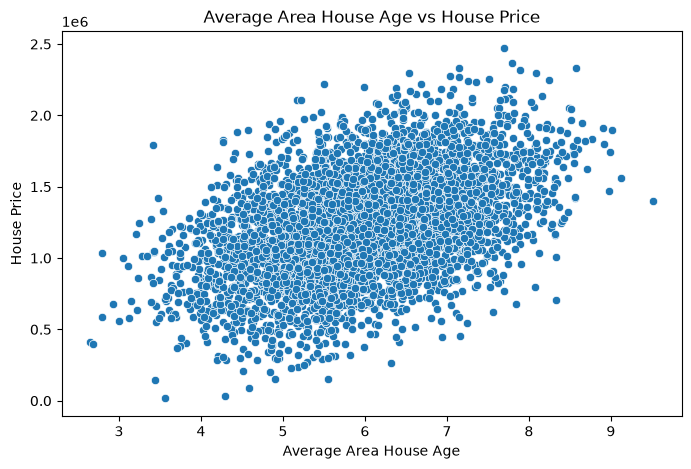

In [23]:
# House Age vs Price
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="avg_area_house_age",
    y="price"
)

plt.title("Average Area House Age vs House Price")
plt.xlabel("Average Area House Age")
plt.ylabel("House Price")

plt.show()

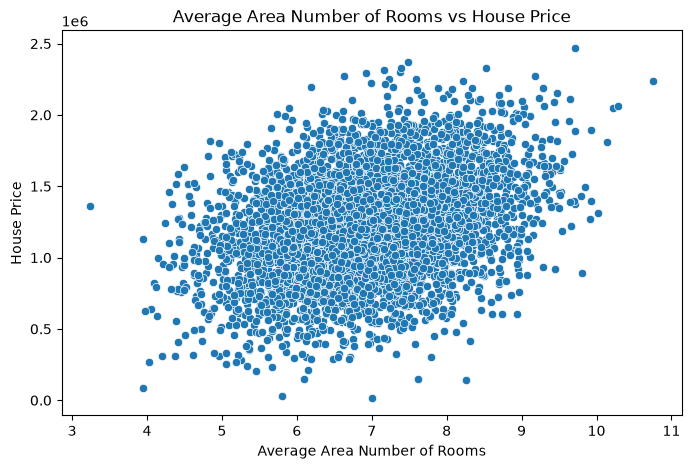

In [24]:
# Number of Rooms vs Price
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="avg_area_number_of_rooms",
    y="price"
)

plt.title("Average Area Number of Rooms vs House Price")
plt.xlabel("Average Area Number of Rooms")
plt.ylabel("House Price")

plt.show()

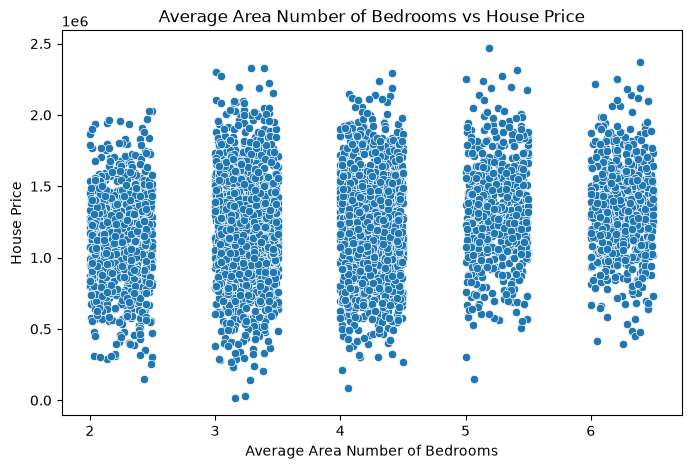

In [25]:
# Number of Bedrooms vs Price
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="avg_area_number_of_bedrooms",
    y="price"
)

plt.title("Average Area Number of Bedrooms vs House Price")
plt.xlabel("Average Area Number of Bedrooms")
plt.ylabel("House Price")

plt.show()

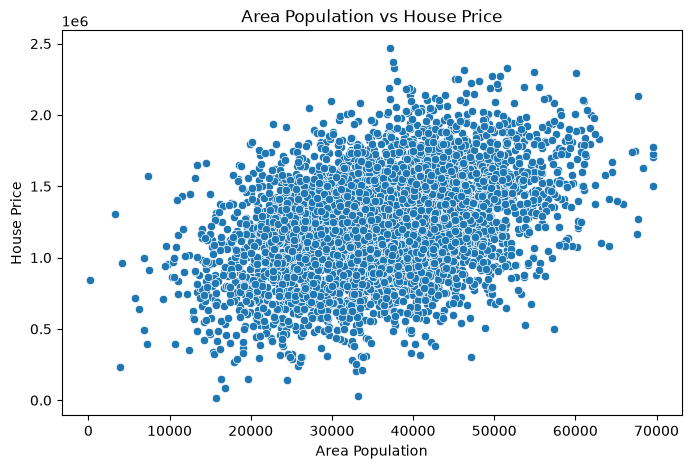

In [26]:
# Area Population vs Price
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="area_population",
    y="price"
)

plt.title("Area Population vs House Price")
plt.xlabel("Area Population")
plt.ylabel("House Price")

plt.show()

In [27]:
# Create rooms per bedroom feature
df["rooms_per_bedroom"] = (
    df["avg_area_number_of_rooms"] /
    df["avg_area_number_of_bedrooms"]
)

# Display the new feature
df[["avg_area_number_of_rooms",
    "avg_area_number_of_bedrooms",
    "rooms_per_bedroom"]].head()

,avg_area_number_of_rooms,avg_area_number_of_bedrooms,rooms_per_bedroom
0,7.009188,4.09,1.713738
1,6.730821,3.09,2.178259
2,8.512727,5.13,1.659401
3,5.586729,3.26,1.713720
4,7.839388,4.23,1.853283


In [28]:
# Check statistics of the new feature
df["rooms_per_bedroom"].describe()

count    5000.000000
mean        1.900368
std         0.554238
min         0.906309
25%         1.455953
50%         1.778737
75%         2.274008
max         3.469229
Name: rooms_per_bedroom, dtype: float64

In [29]:
# Create population categories using quantiles
df["population_category"] = pd.qcut(
    df["area_population"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Check the categories
df["population_category"].value_counts()

population_category
Low       1667
High      1667
Medium    1666
Name: count, dtype: int64

In [30]:
# Check population statistics for each category
df.groupby("population_category", observed=True)["area_population"].describe()

,count,mean,std,min,25%,50%,75%,max
population_category,,,,,,,,
Low,1667.0,25341.089360,5098.658824,172.610686,22593.975826,26411.142277,29403.789820,31800.302253
Medium,1666.0,36164.583726,2479.296857,31818.932565,34108.227529,36199.406689,38180.143493,40456.013364
High,1667.0,46984.875670,5395.168516,40458.735870,42865.210579,45574.741662,49672.786776,69621.713378


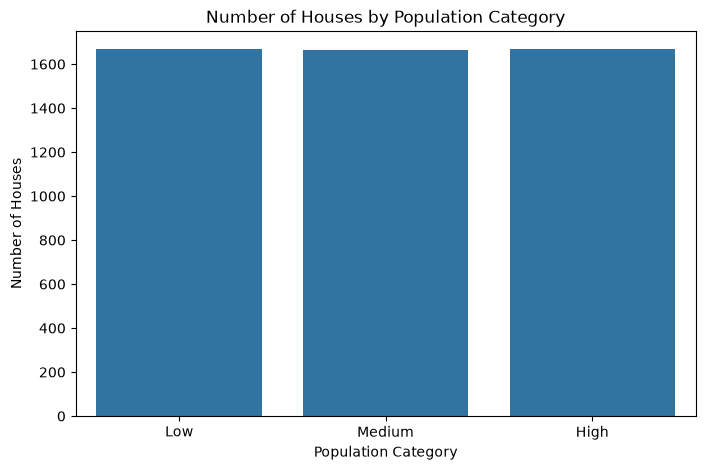

In [31]:
# Visualize population categories
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="population_category"
)

plt.title("Number of Houses by Population Category")
plt.xlabel("Population Category")
plt.ylabel("Number of Houses")

plt.show()

In [32]:
# Display final dataset columns
df.columns

Index(['avg_area_income', 'avg_area_house_age', 'avg_area_number_of_rooms',
       'avg_area_number_of_bedrooms', 'area_population', 'price',
       'rooms_per_bedroom', 'population_category'],
      dtype='str')

In [33]:
# Define input features
X = df[
    [
        "avg_area_income",
        "avg_area_house_age",
        "avg_area_number_of_rooms",
        "avg_area_number_of_bedrooms",
        "area_population",
        "rooms_per_bedroom"
    ]
]

# Define target variable
y = df["price"]

# Display shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 6)
y shape: (5000,)


In [35]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the sizes
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 6)
Testing data: (1000, 6)


In [36]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 6)
X_test: (1000, 6)
y_train: (4000,)
y_test: (1000,)


In [37]:
# Create Linear Regression model
model = LinearRegression()

In [38]:
# Train the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 21.65,164666.05,119511.15, 2641.73, 15.27, 418.16]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['avg_area_income','avg_area_house_age','avg_area_number_of_rooms', 'avg_area_number_of_bedrooms','area_population','rooms_per_bedroom']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.636e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [39]:
# Generate predictions
y_pred = model.predict(X_test)

# Display first 10 predictions
y_pred[:10]

array([1308537.54176885, 1237004.60022188, 1243660.72751176,
       1228835.13173903, 1063377.37073324, 1544026.07661978,
       1094703.25919366,  833242.89921456,  788381.86535794,
       1469659.63599382])

In [40]:
# Compare actual and predicted prices
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,1.339096e+06,1.308538e+06
1,1.251794e+06,1.237005e+06
2,1.340095e+06,1.243661e+06
3,1.431508e+06,1.228835e+06
4,1.042374e+06,1.063377e+06
5,1.555321e+06,1.544026e+06
6,1.250882e+06,1.094703e+06
7,1.039381e+06,8.332429e+05
8,8.324752e+05,7.883819e+05
9,1.420648e+06,1.469660e+06


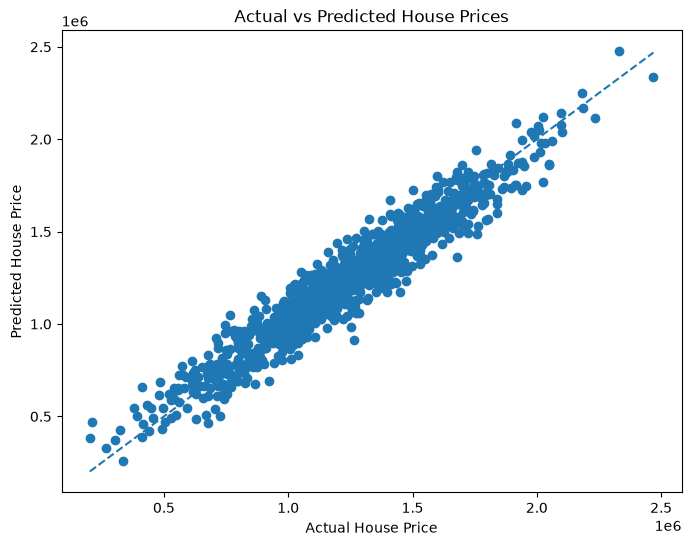

In [41]:
# Plot actual vs predicted prices
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

# Add reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [42]:
plt.savefig("../Images/actual_vs_predicted.png")

<Figure size 640x480 with 0 Axes>

In [43]:
# Calculate R2 Score
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.9179899417844193


In [44]:
# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 80881.06703649044


In [45]:
# Calculate Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 100448.48774410287


In [46]:
# Create model evaluation summary
results = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Value": [r2, mae, rmse]
})

results

,Metric,Value
0,R2 Score,0.917990
1,MAE,80881.067036
2,RMSE,100448.487744


In [47]:
print("Model Evaluation Results")
print("------------------------")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

Model Evaluation Results
------------------------
R2 Score: 0.9180
MAE: 80,881.07
RMSE: 100,448.49


In [48]:
# Get population categories for test data
test_population = df.loc[X_test.index, "population_category"]

# Create comparison DataFrame
category_comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred,
    "Population Category": test_population
})

category_comparison.head()

,Actual Price,Predicted Price,Population Category
1501,1.339096e+06,1.308538e+06,High
2586,1.251794e+06,1.237005e+06,High
2653,1.340095e+06,1.243661e+06,Low
1055,1.431508e+06,1.228835e+06,Low
705,1.042374e+06,1.063377e+06,High


In [49]:
# Calculate MAE for each population category
category_mae = (
    category_comparison
    .groupby("Population Category", observed=True)
    .apply(
        lambda group: mean_absolute_error(
            group["Actual Price"],
            group["Predicted Price"]
        ),
        include_groups=False
    )
)

print("MAE by Population Category")
print(category_mae)

MAE by Population Category
Population Category
Low       80626.647503
Medium    80982.433760
High      81022.410862
dtype: float64


In [50]:
# Create comparison table
category_results = pd.DataFrame({
    "Population Category": category_mae.index,
    "MAE": category_mae.values
})

category_results

,Population Category,MAE
0,Low,80626.647503
1,Medium,80982.433760
2,High,81022.410862


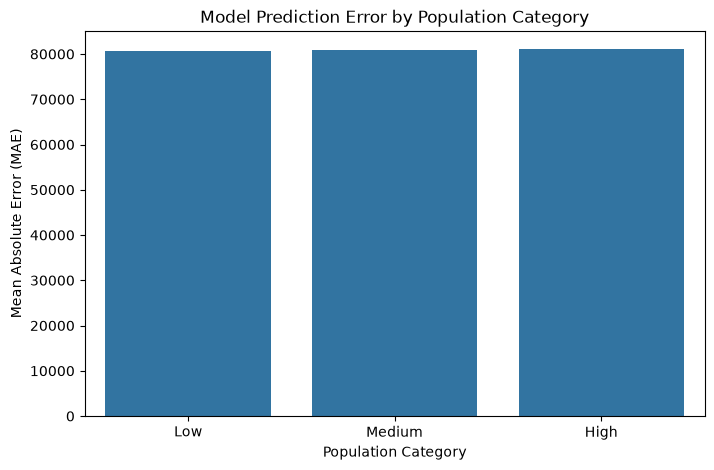

In [51]:
# Plot MAE by population category
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_results,
    x="Population Category",
    y="MAE"
)

plt.title("Model Prediction Error by Population Category")
plt.xlabel("Population Category")
plt.ylabel("Mean Absolute Error (MAE)")

plt.show()